In [22]:
import torch

torch.__version__

'2.11.0+cu128'

In [37]:
weight = 1.1
bias = 0.3

X = torch.arange(0, 5, 0.1).unsqueeze(1)
y = weight * X + bias

In [38]:
train_split = int(0.8 * len(X))

train_split

40

In [39]:
X_train, X_test, y_train, y_test = X[:train_split], X[train_split:], y[:train_split], y[train_split:]

In [40]:
X_test, y_test

(tensor([[4.0000],
         [4.1000],
         [4.2000],
         [4.3000],
         [4.4000],
         [4.5000],
         [4.6000],
         [4.7000],
         [4.8000],
         [4.9000]]),
 tensor([[4.7000],
         [4.8100],
         [4.9200],
         [5.0300],
         [5.1400],
         [5.2500],
         [5.3600],
         [5.4700],
         [5.5800],
         [5.6900]]))

In [83]:
from matplotlib import pyplot as plt


def plot_predictions(train_data, train_labels, test_data, test_labels, predictions = None):
    plt.scatter(train_data, train_labels, c='purple', marker='o', s=2, label='training data')
    plt.scatter(test_data, test_labels, c='lime', marker='o', s=2, label='test data')

    if predictions is not None:
        plt.scatter(test_data, predictions, c='red', marker='o', s=2, label='predictions')

    plt.title('Linear Regression')
    plt.legend()
    plt.show()

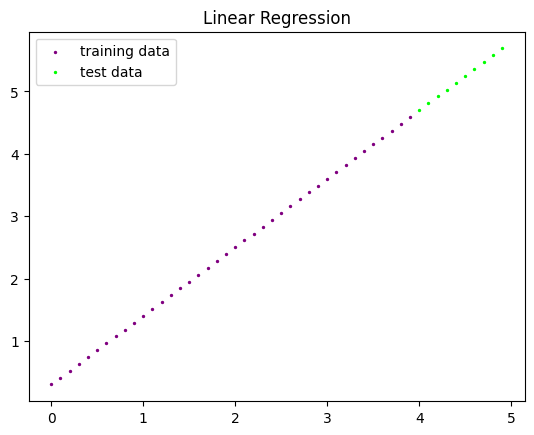

In [64]:
plot_predictions(X_train, y_train, X_test, y_test)

In [67]:
from torch import nn


class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear1(x)


model = LinearRegression()

In [68]:
model.state_dict()

OrderedDict([('linear1.weight', tensor([[-0.2342]])),
             ('linear1.bias', tensor([-0.3450]))])

In [71]:
next(model.parameters())

Parameter containing:
tensor([[-0.2342]], requires_grad=True)

In [77]:
next(model.parameters()).device

device(type='cpu')

In [72]:
model

LinearRegression(
  (linear1): Linear(in_features=1, out_features=1, bias=True)
)

In [74]:
# --- Training ---
# we need:
# - loss function
# - optimizer
# - training loop
# - testing loop

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [76]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [78]:
# TODO put data on the target device

In [79]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    model.train()

    # forward pass
    y_pred = model.forward(X_train)

    # calculate loss
    loss = loss_fn(y_pred, y_train)

    # optimizer zero grad
    optimizer.zero_grad()

    # backpropagation
    loss.backward()

    # calculate gradient / optimizer step
    optimizer.step()

    if epoch % 10 == 0:
        print(f'Epoch {epoch} | Loss {loss.item()}')



Epoch 0 | Loss 3.2467689514160156
Epoch 10 | Loss 2.766519069671631
Epoch 20 | Loss 2.286268711090088
Epoch 30 | Loss 1.8060190677642822
Epoch 40 | Loss 1.3257691860198975
Epoch 50 | Loss 0.8455188870429993
Epoch 60 | Loss 0.36526840925216675
Epoch 70 | Loss 0.01128146331757307
Epoch 80 | Loss 0.016991160809993744
Epoch 90 | Loss 0.01439356803894043
Epoch 100 | Loss 0.01439356803894043
Epoch 110 | Loss 0.01439356803894043
Epoch 120 | Loss 0.01439356803894043
Epoch 130 | Loss 0.01439356803894043
Epoch 140 | Loss 0.01439356803894043
Epoch 150 | Loss 0.01439356803894043
Epoch 160 | Loss 0.01439356803894043
Epoch 170 | Loss 0.01439356803894043
Epoch 180 | Loss 0.01439356803894043
Epoch 190 | Loss 0.01439356803894043


In [85]:
with torch.no_grad():
    model.eval()
    y_preds = model(X_test)

    loss = loss_fn(y_preds, y_test)
    print(loss)

tensor(0.0207)


In [81]:
y_preds

tensor([[4.7195],
        [4.8298],
        [4.9400],
        [5.0503],
        [5.1605],
        [5.2708],
        [5.3810],
        [5.4913],
        [5.6015],
        [5.7118]])

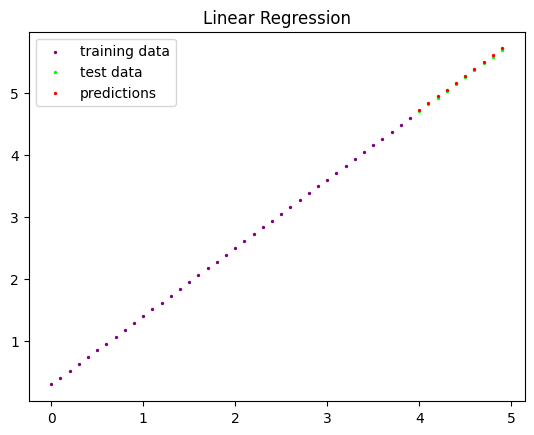

In [84]:
plot_predictions(X_train, y_train, X_test, y_test, y_preds)